In [79]:
import xarray as xr
import numpy as np


from read_PPE_files import get_metrics_names, get_weights_names, restrict_by_common_members, restrict_dataset_by_param

In [133]:
basic_dataset = xr.open_dataset("./PPE_Data/PPE_7_5deg_metrics.nc")
sst4k_dataset =xr.open_dataset("./PPE_Data/sst4k_PPE_7_5deg_metrics.nc")

In [134]:
basic_dataset, _ = restrict_by_common_members(basic_dataset, basic_dataset, sst4k_dataset)



Number of common, unique member pairs: 351


In [135]:
varPrefixes = ["SWCF","LWCF"]
boxSize = 7.5

metric_names = get_metrics_names(varPrefixes,boxSize)


weights_names = get_weights_names(boxSize)

In [136]:
# basic_dataset, _,_ = restrict_dataset_by_param(basic_dataset,basic_dataset,metric_names,-1,lower_bound=100)
# sst4k_dataset,_,_ = restrict_dataset_by_param(sst4k_dataset,sst4k_dataset,metric_names,-1,lower_bound=100)

In [137]:
params_basic = basic_dataset.params.values
params_sst4k = sst4k_dataset.params.values




def get_ratios(metric_names, varPrefixes):

    weights = basic_dataset.isel(time=0,product=0)[weights_names].to_array(dim="metricsNames").to_numpy()
    metricsWeights = np.tile(weights,len(varPrefixes)).reshape(-1,1)

    if not np.allclose(params_basic, params_sst4k):
        print("WRONG")
        return
    else:
        basic_default = basic_dataset.sel(ens_idx="ctrl").isel(time=0,product=0)[metric_names]
        sst4k_default = sst4k_dataset.sel(ens_idx='ctrl').isel(time=0,product=0)[metric_names]

        vals_basic = basic_dataset.isel(product=0, time=0)[metric_names]
        vals_basic_no_default = vals_basic.drop_sel(ens_idx='ctrl')
        vals_sst4k = sst4k_dataset.isel(product=0, time=0)[metric_names]
        vals_sst4k_no_default = vals_sst4k.drop_sel(ens_idx='ctrl')
        
        vals_basic_centered = (basic_default-vals_basic_no_default).to_array().values
        # vals_basic_centered_weighted = vals_basic_centered * metricsWeights
        vals_sst4k_centered = (sst4k_default-vals_sst4k_no_default).to_array().values
        # vals_sst4k_centered_weighted = vals_sst4k_centered * metricsWeights

        denominator = np.sum(vals_basic_centered**2, axis=0)
        numerator = np.sum(vals_sst4k_centered**2, axis=0)

        ratios_array = numerator / denominator
        ratios = ratios_array.tolist()
    
    return ratios

In [138]:
ratios_swcf_lwcf = get_ratios(metric_names,["SWCF","LWCF"])

ratios_swcf = get_ratios(metric_names[:1152],["SWCF"])

ratios_lwcf = get_ratios(metric_names[1152:],["LWCF"])



In [91]:
weights = basic_dataset.isel(time=0,product=0)[weights_names].to_array(dim="metricsNames").to_numpy()
np.sum(weights)

np.float64(0.9999999999999998)

In [93]:
basic_default = basic_dataset.sel(ens_idx="ctrl").isel(time=0,product=0)
sst4k_default = sst4k_dataset.sel(ens_idx='ctrl').isel(time=0,product=0)

vals_basic = basic_dataset.isel(product=0, time=0)
vals_basic_no_default = vals_basic.drop_sel(ens_idx='ctrl')



In [139]:
print("SWCF+LWCF")
print(np.argmax(ratios_swcf_lwcf))
print(np.max(ratios_swcf_lwcf))
print("SWCF")
print(np.argmax(ratios_swcf))
print(np.max(ratios_swcf))
print("LWCF")
print(np.argmax(ratios_lwcf))
print(np.max(ratios_lwcf))

SWCF+LWCF
284
2.4618748230645737
SWCF
346
2.508473681531235
LWCF
49
3.3456177261856697


2.0060963755407513

In [123]:
swcf_top_idxs = np.argsort(ratios_swcf)[-10:]
swcf_lwcf_top_idxs = np.argsort(ratios_swcf_lwcf)[-10:]
lwcf_top_idxs = np.argsort(ratios_lwcf)[-10:]

default_params = basic_dataset.sel(ens_idx="ctrl").params.values

PPE_params = vals_basic_no_default.params.values

print(len(ratios_swcf))
print(len(vals_basic_no_default.ens_idx))

min_params = np.min(PPE_params, axis=0)
max_params = np.max(PPE_params, axis=0)

idxs = lwcf_top_idxs

top_ratio_params = (vals_basic_no_default.isel(ens_idx=idxs).params.values - default_params)/(max_params-min_params)

print(vals_basic_no_default.isel(ens_idx=idxs).params.values[:,-1])
print(idxs)

27
27
[12669490.   6265089.5 13443906.   5939312.  25286432.  12946224.
 29610662.   9408521.  27190754.  25051434. ]
[ 9 21  0 15 14 24 26 23  4  2]


In [ ]:
print(np.sort(swcf_top_idxs))
print(np.sort(lwcf_top_idxs))
param_names = ['clubb_c1',
        'clubb_gamma_coef',
        'zmconv_tau',
        'zmconv_dmpdz',
        'zmconv_micro_dcs',
        'nucleate_ice_subgrid',
        'p3_nc_autocon_expon',
        'p3_qc_accret_expon',
        'zmconv_auto_fac',
        'zmconv_accr_fac',
        'zmconv_ke',
        'cldfrc_dp1',
        'p3_embryonic_rain_size',
        'p3_mincdnc'
        ]


vals_basic_no_default.params[swcf_top_idxs[-2]]

[ 0  2  3  4  6 15 16 17 23 26]
[ 0  2  4  9 14 15 21 23 24 26]


<xarray.DataArray 'params' (input_param: 14)> Size: 56B
array([ 2.620716e+00,  2.498686e-01,  6.147842e+03, -7.545568e-04,
        3.502222e-04,  1.249893e+00, -1.559277e+00,  1.172940e+00,
        5.052248e+00,  1.679435e+00,  1.296665e-06,  4.017715e-02,
        2.063140e-05,  9.408521e+06], dtype=float32)
Coordinates:
    ens_idx  <U75 300B 'ens/workdir.396/20230802.v3alpha02.F2010.pmcpu.intel.8N'
    workdir  <U75 300B ...
    product  <U3 12B 'mod'
    time     <U3 12B 'ANN'
Dimensions without coordinates: input_param

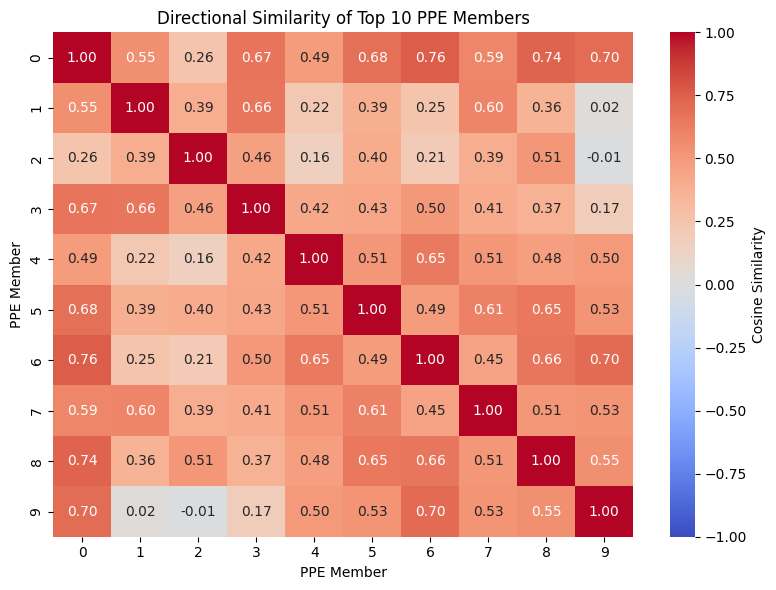

In [125]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity


top_10_members = top_ratio_params


similarity_matrix = cosine_similarity(top_10_members)


plt.figure(figsize=(8, 6))
sns.heatmap(similarity_matrix, 
            annot=True,          
            fmt=".2f",           
            cmap="coolwarm",     
            vmin=-1.0,           
            vmax=1.0,            
            cbar_kws={'label': 'Cosine Similarity'})

plt.title("Directional Similarity of Top 10 PPE Members")
plt.xlabel("PPE Member")
plt.ylabel("PPE Member")
plt.tight_layout()


In [127]:
print(np.array(ratios_swcf)[swcf_top_idxs])

print(np.array(ratios_swcf_lwcf)[swcf_top_idxs])

[1.55748049 1.60576441 1.62130052 1.67577922 1.70192074 1.72233993
 1.79463847 1.91614048 1.97575162 2.50847368]
[1.59994569 1.61830094 1.85840676 1.6382403  1.78352346 1.71174586
 1.67904173 1.95086637 1.95116909 2.34101077]


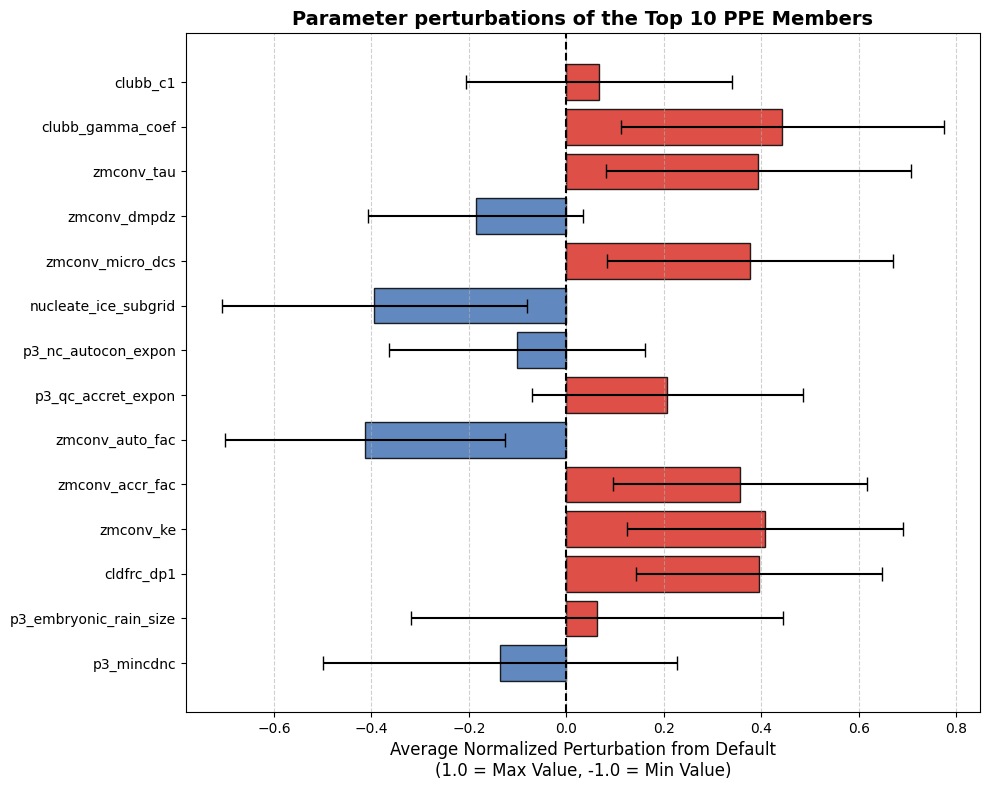

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


param_names = ['clubb_c1',
        'clubb_gamma_coef',
        'zmconv_tau',
        'zmconv_dmpdz',
        'zmconv_micro_dcs',
        'nucleate_ice_subgrid',
        'p3_nc_autocon_expon',
        'p3_qc_accret_expon',
        'zmconv_auto_fac',
        'zmconv_accr_fac',
        'zmconv_ke',
        'cldfrc_dp1',
        'p3_embryonic_rain_size',
        'p3_mincdnc'
        ]



mean_direction = np.mean(top_ratio_params, axis=0)
std_direction = np.std(top_ratio_params, axis=0)

plt.figure(figsize=(10, 8))

colors = ['#d73027' if val > 0 else '#4575b4' for val in mean_direction]


bars = plt.barh(param_names, mean_direction, xerr=std_direction, color=colors, 
                edgecolor='black', capsize=5, alpha=0.85)


plt.axvline(0, color='black', linewidth=1.5, linestyle='--')


plt.xlabel("Average Normalized Perturbation from Default\n(1.0 = Max Value, -1.0 = Min Value)", fontsize=12)
plt.title("Parameter perturbations of the Top 10 PPE Members", fontsize=14, fontweight='bold')
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.gca().invert_yaxis()

plt.tight_layout()
plt.savefig("top10_parameter_lwcf_fingerprint.png", dpi=300)

In [159]:

norms = np.linalg.norm(top_ratio_params, axis=1, keepdims=True)
unit_vectors = top_ratio_params/ norms
print(np.linalg.norm(unit_vectors,axis=1))

mean_unit_vector = np.mean(unit_vectors, axis=0)

mrl = np.linalg.norm(mean_unit_vector)

print(f"Mean Resultant Length (MRL): {mrl:.3f}")

[1.0000001  0.99999994 0.99999994 0.99999994 1.         0.99999994
 1.         1.         0.99999994 1.        ]
Mean Resultant Length (MRL): 0.723


In [150]:
oaat_names = ['clubb_c1', 'clubb_gamma_coef', 'zmconv_tau', 'zmconv_dmpdz', 'zmconv_ke', 'zmconv_micro_dcs','zmconv_auto_fac', 'zmconv_accr_fac', 'p3_nc_autocon_expon', 'p3_qc_accret_expon', 'p3_embryonic_rain_size', 'p3_mincdnc', 'cldfrc_dp1', 'nucleate_ice_subgrid']

emulator_result = [ 2.62243503e+00  ,1.51414866e-01 , 3.64839742e+03 ,-6.08790763e-04,
  4.99999999e-07 , 3.99999990e-04 , 5.53264675e+00, 1.47862971e+00,
 -1.45857677e+00,  1.19064669e+00 , 1.49999996e-05 , 2.62429884e+07,
  1.23889350e-02 , 1.35137671e+00]

emulator_dict = dict(zip(oaat_names, emulator_result))
emulator_result_raw = np.array([emulator_dict[name] for name in param_names])

emulator_res_scaled = (emulator_result_raw - default_params)/(max_params-min_params)

similarity = cosine_similarity(emulator_res_scaled.reshape(1,-1),mean_unit_vector.reshape(1,-1))
similarity


array([[0.32320136]])

In [155]:
ppe_emulator_result= np.array([1.13612799e+00 , 2.55110832e-01 , 2.23561222e+03 ,-8.57208441e-04,
  3.43785012e-04  ,1.37567369e+00 ,-1.64216681e+00 , 1.10123217e+00,
  3.10126674e+00 , 1.51304615e+00,  9.89281689e-06  ,6.97740791e-02,
  3.56949283e-05 , 2.80703522e+07])
ppe_emulator_res_scaled = (ppe_emulator_result - default_params)/(max_params-min_params)
similarity = cosine_similarity(ppe_emulator_res_scaled.reshape(1,-1),mean_unit_vector.reshape(1,-1))
similarity

array([[0.49099199]])

In [156]:
ppe_emulator_res_scaled

array([-0.3288116 ,  0.34048053, -0.11245361, -0.088074  ,  0.77004234,
        0.14478963, -0.4567913 , -0.24731672, -0.95773263,  0.02769312,
        0.83599811,  0.59676954,  0.47257385,  0.34093333])